# 日経225　データ取得　& 基本統計分析

##　目的
- yfinanceを使って日経225の過去5年分データを取得
- 基本統計量を確認し、データの特徴を把握する
- 可視化で直感的に理解する

## 使用ライブラリ
- 'yfinance' : 株価データ取得
- 'pandas' : データ操作
- 'matplotlib' / 'seaborn' : 可視化
- 'scipy' :統計検定 (Notebook 2 で使用) 

In [4]:
# ライブラリのインポート
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# グラフの日本語対応（必要に応じて）
plt.rcParams['figure.figsize']= (12, 6)
plt.rcParams['font.size']= 12
sns.set_style('whitegrid')

print("ライブラリのインポート完了")
print(f" 実行日時: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

ライブラリのインポート完了
 実行日時: 2026-04-01 22:30


## 1. データ取得
yfinance で日経225 (^N225)の過去5年分データを取得する

In [5]:
#日経225のデータを取得（過去5年分）
ticker = '^N225'
nikkei = yf.download(ticker, start='2019-01-01')

# 基本情報を確認
print(f"【データ取得結果】")
print(f" 銘柄:{ticker} (日経225) ")
print(f" 期間: {nikkei.index[0].strftime('%Y-%m-%d')} ~ {nikkei.index[-1].strftime('%Y-%m-%d')} ")
print(f" 行数: {len(nikkei)} 日分")
print(f" 列数:{nikkei.shape[1]}")
print(f"\n【最初の5行】")
nikkei.head()

[*********************100%***********************]  1 of 1 completed

【データ取得結果】
 銘柄:^N225 (日経225) 
 期間: 2019-01-04 ~ 2026-04-01 
 行数: 1765 日分
 列数:5

【最初の5行】


Price,Close,High,Low,Open,Volume
Ticker,^N225,^N225,^N225,^N225,^N225
Date,,,,,
2019-01-04,19561.960938,19692.580078,19241.369141,19655.130859,91600000
2019-01-07,20038.970703,20266.220703,19920.800781,19944.609375,81500000
2019-01-08,20204.039062,20347.919922,20106.359375,20224.669922,86400000
2019-01-09,20427.060547,20494.349609,20331.199219,20366.300781,72800000
2019-01-10,20163.800781,20345.919922,20101.929688,20270.880859,73700000


In [19]:
#カラムの平坦化(yfinanceのMultiIndex 対策)
nikkei.columns = nikkei.columns.get_level_values(0)
print(f"✓ カラム修正完了: {list(nikkei.columns)}")

✓ カラム修正完了: ['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return']


## 2. 基本統計量の確認
データの全体像を数値で把握する。平均・標準偏差・最大・最小などを確認

In [20]:
# 基本統計量
print("【基本統計量】")
print(nikkei['Close'].describe())

print(f"\n【追加情報】")
print(f" 期間中の最高値: {nikkei['Close'].max():,.0f} 円")
print(f" 期間中の最安値: {nikkei['Close'].min():,.0f} 円")
print(f"  価格レンジ:     {nikkei['Close'].max() - nikkei['Close'].min():,.0f} 円")
print(f"  欠損値の数:     {nikkei['Close'].isnull().sum()} 個")

【基本統計量】
count     1765.000000
mean     31031.500018
std       8485.463474
min      16552.830078
25%      24041.259766
50%      28606.759766
75%      37723.910156
max      58850.269531
Name: Close, dtype: float64

【追加情報】
 期間中の最高値: 58,850 円
 期間中の最安値: 16,553 円
  価格レンジ:     42,297 円
  欠損値の数:     0 個


## 3. 日次リターンの計算
株価の「変化率」を計算する。前日比で何％動いたかを見ることで、価格の絶対値ではなく「動きの大きさ」を分析できる。

**計算式:** 日次リターン= (今日の終値-昨日の終値)/昨日の終値 × 100

In [21]:
#日次リターン(%)を計算
nikkei['Daily_Return'] = nikkei['Close'].pct_change() * 100

print("【日次リターンの統計】")
print(nikkei['Daily_Return'].describe())
print(f"\n  最大上昇日: {nikkei['Daily_Return'].max():.2f}%")
print(f"  最大下落日: {nikkei['Daily_Return'].min():.2f}%")
print(f"  平均リターン: {nikkei['Daily_Return'].mean():.4f}%")

【日次リターンの統計】
count    1764.000000
mean        0.066551
std         1.359222
min       -12.395758
25%        -0.614997
50%         0.084329
75%         0.767413
max        10.226327
Name: Daily_Return, dtype: float64

  最大上昇日: 10.23%
  最大下落日: -12.40%
  平均リターン: 0.0666%


##4. 可視化
##4-1. 株価の推移（終値）

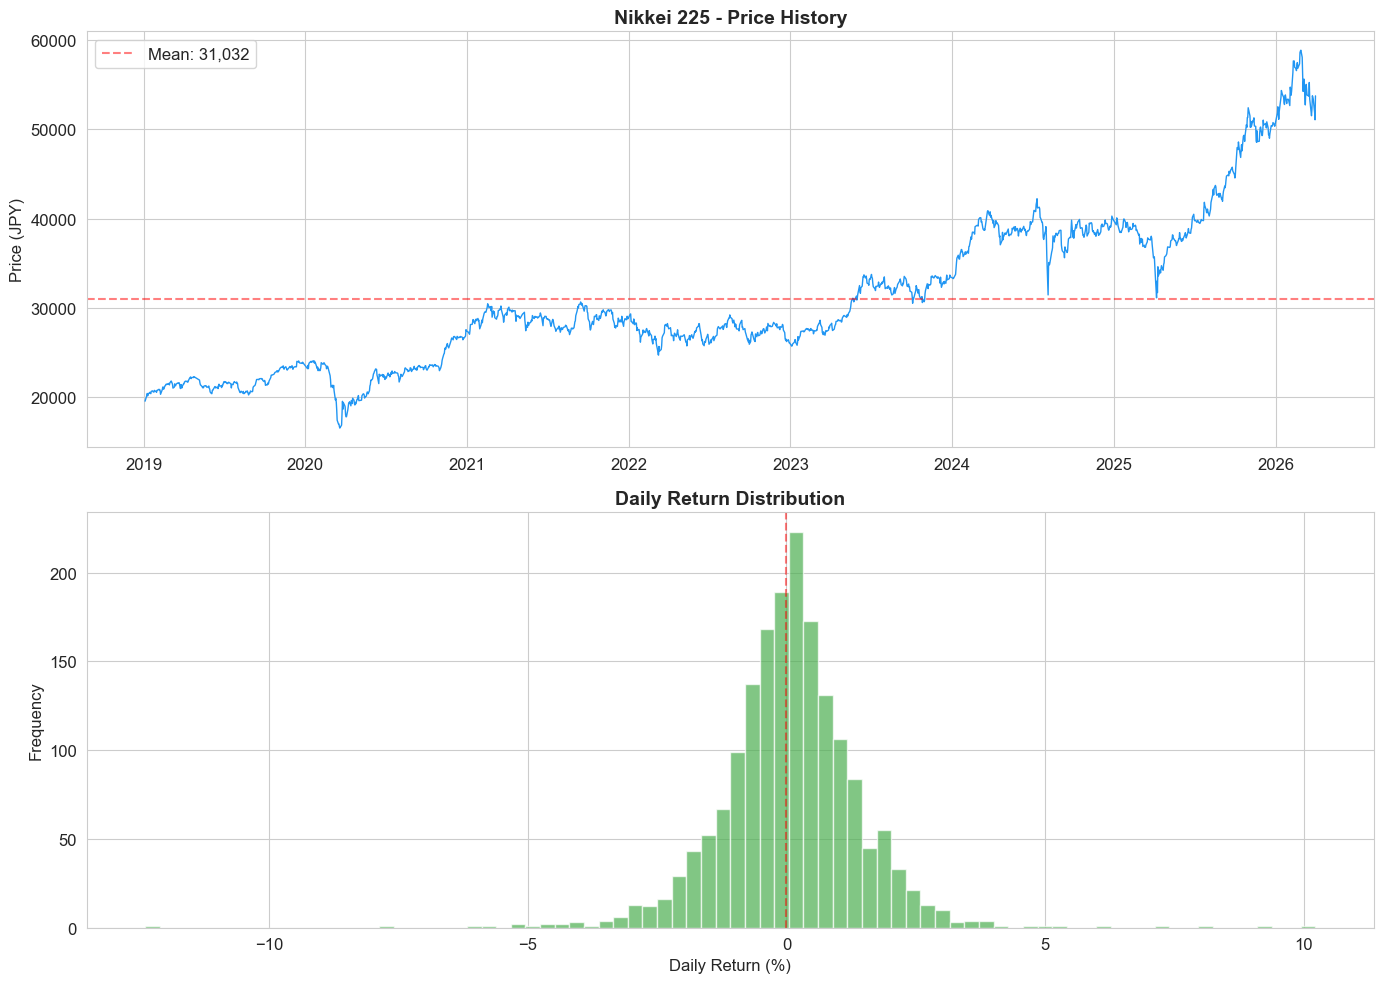

✓ グラフを保存: nikkei225_overview.png


In [23]:
#株価推移グラフ
fig, axes = plt.subplots(2,1, figsize=(14, 10))

#上段：株価推移
axes[0].plot(nikkei.index, nikkei['Close'], color='#2196F3', linewidth=1)
axes[0].set_title('Nikkei 225 - Price History', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (JPY)')
axes[0].axhline(y=nikkei['Close'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {nikkei["Close"].mean():,.0f}')
axes[0].legend()

#下段:日次リターン分布
axes[1].hist(nikkei['Daily_Return'].dropna(), bins=80, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1].set_title('Daily Return Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nikkei225_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ グラフを保存: nikkei225_overview.png")